# 04 – Early-2026 Out-of-Sample Validation of NVI

## 1. Objective

This notebook evaluates the **Narrative Volatility Index (NVI)** in an out-of-sample setting.

The main NVI framework was constructed using country-level volatility components. In this notebook, **2025** is used as the baseline period, and **early-2026 observations** are evaluated using the same baseline normalization parameters.

Because the 2026 data covers only the **first three months of the year**, the results should be interpreted as an **early-2026 comparison** rather than a full-year validation.

The main objectives are:

- recomputing rolling volatility across the full available timeline,
- extracting comparable **2025** and **early-2026** country-level snapshots,
- using **2025** as the baseline normalization period,
- calculating NVI values for 2025 and 2026 on the same scale,
- measuring changes in NVI between 2025 and early 2026,
- validating the recalculated 2025 NVI against the main NVI table,
- identifying countries with increasing or decreasing narrative volatility,
- analyzing regime shifts between 2025 and early 2026,
- examining whether major conflict environments during early 2026, especially the **Iran–Israel–Gulf escalation**, are reflected in NVI changes.

This notebook does **not** claim that wars or conflicts directly caused the observed NVI changes. Instead, it evaluates whether NVI shifts are **descriptively aligned** with major conflict-related developments during the same period.

## 2. Setup and Data Source

The analysis uses the same DuckDB database created in the previous notebooks. The input data comes from the country-month narrative indicators and volatility components generated during the NVI construction process.

The required Python libraries are imported first.

In [53]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("../data/intermediate/gdelt_main.db")

## 3. Recomputing Rolling Volatility on the Full Timeline

Rolling volatility is recomputed across the full available country-month timeline before extracting yearly snapshots.

This is important because rolling volatility depends on previous months. If the data were filtered too early, the rolling window for 2026 would lose historical context. Therefore, the rolling volatility calculation is performed first, and the 2025/2026 snapshots are extracted afterward.

In [54]:
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_month;
""")

## 4. Creating 2025 and 2026 Snapshots

After rolling volatility is computed, country-level snapshots are created for the comparison periods.

The 2025 snapshot represents the baseline period. The 2026 snapshot represents the out-of-sample period. Both snapshots are constructed for the same set of countries to ensure that the comparison is consistent.

In [55]:
filtered_2025 = con.execute("""
SELECT country,
       SUM(event_count) AS total_events,
       MIN(event_count) AS min_monthly_events
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
GROUP BY country
HAVING total_events >= 60
   AND min_monthly_events >= 10
""").fetchdf()

In [56]:
nvi_2025 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2025-12-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

nvi_2026 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2026-03-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

In [57]:
nvi_2025 = nvi_2025.rename(columns={
    "tone_vol": "tone_2025",
    "goldstein_vol": "goldstein_2025",
    "entropy_vol": "entropy_2025"
})

nvi_2026 = nvi_2026.rename(columns={
    "tone_vol": "tone_2026",
    "goldstein_vol": "goldstein_2026",
    "entropy_vol": "entropy_2026"
})

In [58]:
merged = nvi_2025.merge(nvi_2026, on="country", how="inner")

comparison_sample_summary = pd.DataFrame({
    "metric": ["Countries used in 2025–early 2026 comparison"],
    "value": [merged.shape[0]]
})

comparison_sample_summary

,metric,value
0,Countries used in 2025–early 2026 comparison,211


## 5. Baseline Normalization

The NVI components are normalized using only the **2025 baseline distribution**. This means that the mean and standard deviation of each volatility component are estimated from the 2025 snapshot.

The same baseline parameters are then applied to both 2025 and 2026. This allows the 2026 NVI values to be interpreted relative to the 2025 baseline scale.

This step is essential for out-of-sample validation because it avoids recalculating the scale separately for 2026.

In [59]:
mu_tone = merged["tone_2025"].mean()
std_tone = merged["tone_2025"].std()

mu_gold = merged["goldstein_2025"].mean()
std_gold = merged["goldstein_2025"].std()

mu_entropy = merged["entropy_2025"].mean()
std_entropy = merged["entropy_2025"].std()

## 6. Computing NVI on the 2025 Baseline Scale

After estimating the baseline normalization parameters from 2025, NVI values are computed for both years using the same scale.

The 2025 NVI represents the baseline score, while the 2026 NVI shows how each country appears when evaluated against the 2025 volatility structure.

In [60]:
merged["z_tone_2025"] = (merged["tone_2025"] - mu_tone) / std_tone
merged["z_gold_2025"] = (merged["goldstein_2025"] - mu_gold) / std_gold
merged["z_entropy_2025"] = (merged["entropy_2025"] - mu_entropy) / std_entropy

merged["NVI_2025"] = (
    merged["z_tone_2025"] +
    merged["z_gold_2025"] +
    merged["z_entropy_2025"]
)

In [61]:
merged["z_tone_2026"] = (merged["tone_2026"] - mu_tone) / std_tone
merged["z_gold_2026"] = (merged["goldstein_2026"] - mu_gold) / std_gold
merged["z_entropy_2026"] = (merged["entropy_2026"] - mu_entropy) / std_entropy

merged["NVI_2026"] = (
    merged["z_tone_2026"] +
    merged["z_gold_2026"] +
    merged["z_entropy_2026"]
)

## 7. Delta NVI Analysis

The change in narrative volatility is measured using the difference between 2026 and 2025 NVI values.

A positive `delta_NVI` indicates that a country's narrative volatility increased in 2026 relative to the 2025 baseline. A negative value indicates that narrative volatility decreased.

In [62]:
merged["delta_NVI"] = merged["NVI_2026"] - merged["NVI_2025"]

Countries with the largest positive `delta_NVI` represent cases where narrative volatility increased the most relative to the baseline. Countries with the largest negative `delta_NVI` represent cases where narrative volatility decreased the most.

## 8. Validation Against the Main NVI Table

The recalculated 2025 NVI is compared with the main NVI values from the previous notebook. This check verifies that the baseline recomputation is consistent with the original NVI construction.

A very small maximum difference indicates that the recomputed baseline NVI matches the original NVI values and that the out-of-sample validation pipeline is internally consistent.

In [63]:
baseline = con.execute("""
SELECT country, NVI
FROM narrative_nvi
""").fetchdf()

test = baseline.merge(merged[["country","NVI_2025"]], on="country")

test["diff"] = test["NVI"] - test["NVI_2025"]

max_diff = test["diff"].abs().max()

validation_summary = pd.DataFrame({
    "metric": ["Maximum absolute difference"],
    "value": [max_diff]
})

validation_summary

,metric,value
0,Maximum absolute difference,3.108624e-15


The maximum difference is around \(10^{-15}\), which is effectively zero and reflects only floating-point precision differences. This confirms that the recalculated 2025 baseline NVI is consistent with the main NVI construction pipeline.

## 9. Distribution Shift Analysis

The distributions of 2025 and 2026 NVI values are compared to inspect whether the overall narrative volatility structure shifted between the baseline and evaluation periods.

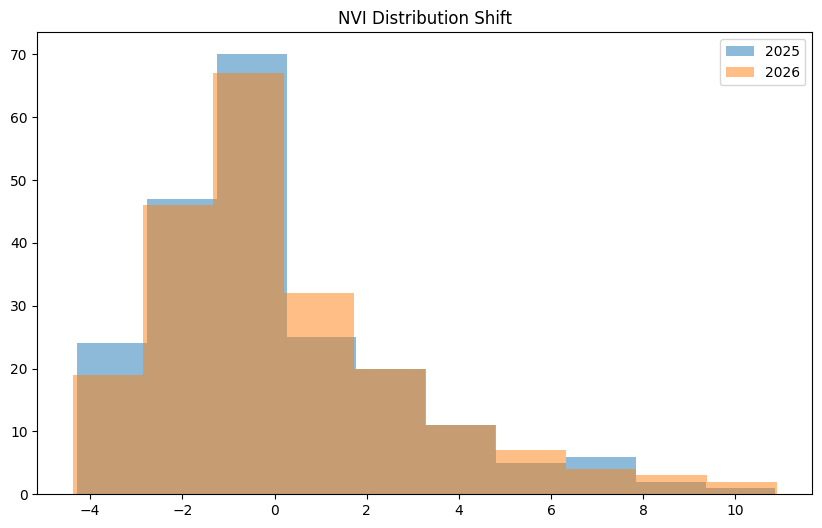

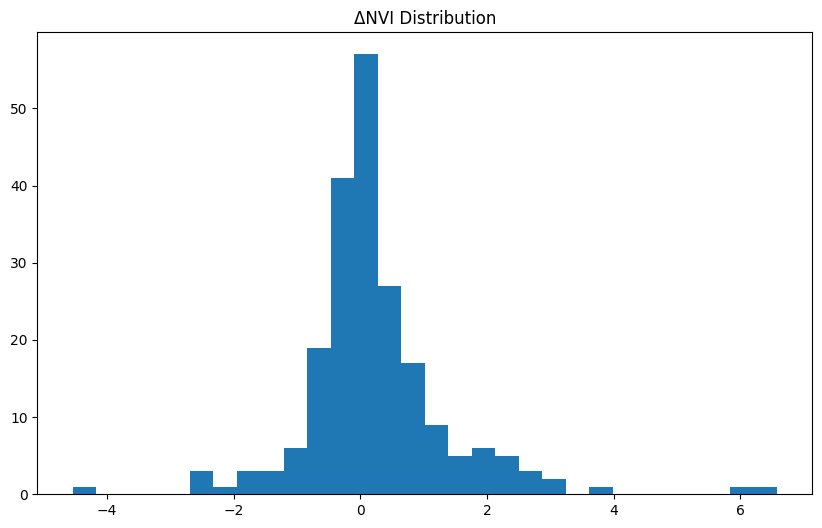

In [64]:
plt.figure(figsize=(10,6))
plt.hist(merged["NVI_2025"], alpha=0.5, label="2025")
plt.hist(merged["NVI_2026"], alpha=0.5, label="2026")
plt.legend()
plt.title("NVI Distribution Shift")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged["delta_NVI"], bins=30)
plt.title("ΔNVI Distribution")
plt.show()

## 10. Regime Shift Analysis

Countries are assigned to regimes based on the 2025 NVI distribution, and the same thresholds are applied to 2026 values. This allows regime changes to be interpreted relative to the baseline year.

The regime transition analysis shows whether countries moved from `Stable` to `Moderate`, from `Moderate` to `Shock`, or in the opposite direction between 2025 and 2026.

In [65]:
q25 = merged["NVI_2025"].quantile(0.25)
q75 = merged["NVI_2025"].quantile(0.75)

def regime(x):
    if x > q75:
        return "Shock"
    elif x < q25:
        return "Stable"
    else:
        return "Moderate"

merged["regime_2025"] = merged["NVI_2025"].apply(regime)
merged["regime_2026"] = merged["NVI_2026"].apply(regime)

merged["regime_change"] = merged["regime_2025"] + " → " + merged["regime_2026"]

In [66]:
top_positive_shifts = merged.sort_values("delta_NVI", ascending=False)[[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026",
    "regime_change"
]].head(10)

top_positive_shifts

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026,regime_change
92,BHR,-0.513215,6.067970,6.581186,Moderate,Shock,Moderate → Shock
96,KWT,-0.238648,5.732120,5.970768,Moderate,Shock,Moderate → Shock
33,ARE,-1.235715,2.645284,3.880999,Moderate,Shock,Moderate → Shock
204,IRQ,-2.688478,0.302389,2.990867,Stable,Moderate,Stable → Moderate
107,OMN,0.723203,3.646784,2.923581,Moderate,Shock,Moderate → Shock
101,SAU,-1.831909,0.949078,2.780987,Stable,Moderate,Stable → Moderate
138,QAT,0.113307,2.825710,2.712403,Moderate,Shock,Moderate → Shock
135,MHL,3.299954,5.893928,2.593974,Shock,Shock,Shock → Shock
44,AFG,-1.269015,1.112376,2.381391,Moderate,Shock,Moderate → Shock
161,IRN,-1.395491,0.910231,2.305722,Moderate,Moderate,Moderate → Moderate


In [67]:
top_negative_shifts = merged.sort_values("delta_NVI", ascending=True)[[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026",
    "regime_change"
]].head(10)

top_negative_shifts

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026,regime_change
99,RWA,3.666648,-0.874565,-4.541213,Shock,Moderate,Shock → Moderate
35,BDI,9.185717,6.752223,-2.433494,Shock,Shock,Shock → Shock
10,AGO,2.843177,0.421787,-2.421390,Shock,Moderate,Shock → Moderate
200,AIA,4.901758,2.527745,-2.374013,Shock,Shock,Shock → Shock
0,COD,2.293372,0.006936,-2.286435,Shock,Moderate,Shock → Moderate
82,KOR,-0.363373,-2.099879,-1.736506,Moderate,Stable,Moderate → Stable
139,SWE,-0.585665,-2.313156,-1.727491,Moderate,Stable,Moderate → Stable
152,SLV,0.382126,-1.226747,-1.608872,Moderate,Moderate,Moderate → Moderate
1,CRI,0.888709,-0.676416,-1.565125,Moderate,Moderate,Moderate → Moderate
119,SSD,-0.541221,-1.848295,-1.307073,Moderate,Stable,Moderate → Stable


In [68]:
regime_transition_summary = merged["regime_change"].value_counts().reset_index()
regime_transition_summary.columns = ["regime_change", "country_count"]

regime_transition_summary

,regime_change,country_count
0,Moderate → Moderate,84
1,Shock → Shock,49
2,Stable → Stable,42
3,Moderate → Shock,14
4,Stable → Moderate,11
5,Moderate → Stable,7
6,Shock → Moderate,4


The regime transition analysis shows how countries move across **Stable**, **Moderate**, and **Shock** categories when 2026 values are evaluated using the 2025 baseline thresholds.

A movement into the **Shock** regime indicates that a country’s narrative volatility increased enough to exceed the 2025 upper-threshold level. A movement into the **Stable** regime indicates a relative decrease in volatility compared with the 2025 baseline.

These transitions should be interpreted as **relative changes in narrative volatility**, not as direct evidence of conflict escalation or de-escalation.

## 11. Middle East and Gulf Case Analysis

This section focuses on selected Middle East and Gulf countries to inspect how NVI changed between 2025 and early 2026 within a politically salient regional subset.

The analysis is descriptive. It does not claim to explain the causes of geopolitical events; rather, it shows how the NVI framework can be used to compare changes in narrative volatility across selected countries.

### 11.1 Middle East and Gulf NVI Table

In [69]:
middle_east_gulf = [
    "TUR", "IRN", "IRQ", "SYR", "SAU", "ARE", "QAT", "KWT", 
    "OMN", "BHR", "YEM", "JOR", "LBN", "ISR", "PSE"
]

me_df = merged[merged["country"].isin(middle_east_gulf)].copy()

### 11.2 NVI 2025 vs NVI 2026 Scatter Plot

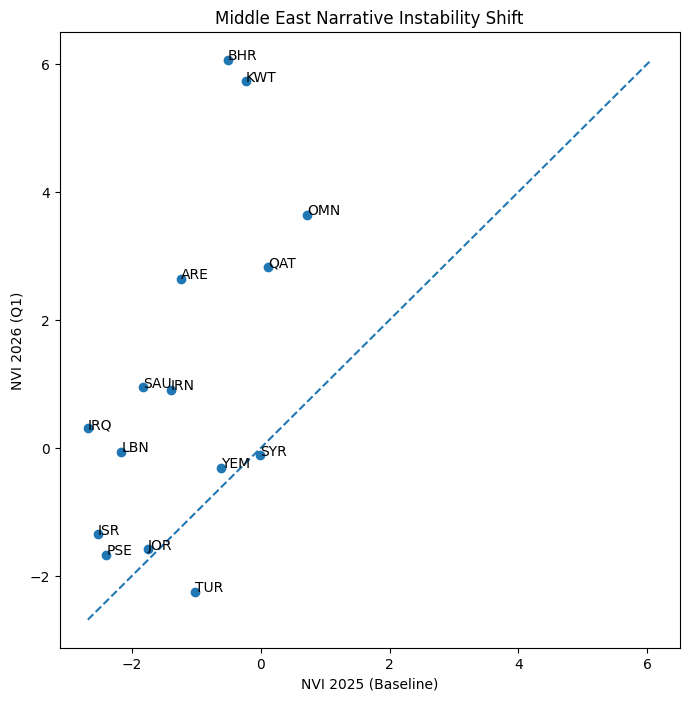

In [70]:
plt.figure(figsize=(8,8))

plt.scatter(me_df["NVI_2025"], me_df["NVI_2026"])

# diagonal line
min_val = min(me_df["NVI_2025"].min(), me_df["NVI_2026"].min())
max_val = max(me_df["NVI_2025"].max(), me_df["NVI_2026"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# label countries
for _, row in me_df.iterrows():
    plt.text(row["NVI_2025"], row["NVI_2026"], row["country"])

plt.xlabel("NVI 2025 (Baseline)")
plt.ylabel("NVI 2026 (Q1)")
plt.title("Middle East Narrative Instability Shift")

plt.show()

### 11.3 Delta NVI by Country

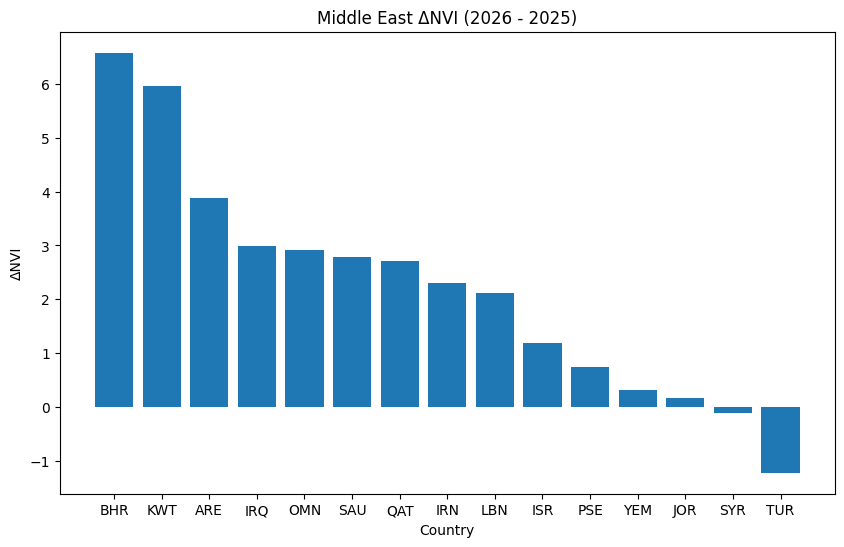

In [71]:
me_df = me_df.sort_values("delta_NVI", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(me_df["country"], me_df["delta_NVI"])

plt.title("Middle East ΔNVI (2026 - 2025)")
plt.xlabel("Country")
plt.ylabel("ΔNVI")

plt.show()

In [72]:
me_table = merged[merged["country"].isin(middle_east_gulf)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

me_table

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026
92,BHR,-0.513215,6.067970,6.581186,Moderate,Shock
96,KWT,-0.238648,5.732120,5.970768,Moderate,Shock
33,ARE,-1.235715,2.645284,3.880999,Moderate,Shock
204,IRQ,-2.688478,0.302389,2.990867,Stable,Moderate
107,OMN,0.723203,3.646784,2.923581,Moderate,Shock
101,SAU,-1.831909,0.949078,2.780987,Stable,Moderate
138,QAT,0.113307,2.825710,2.712403,Moderate,Shock
161,IRN,-1.395491,0.910231,2.305722,Moderate,Moderate
103,LBN,-2.167016,-0.059593,2.107423,Stable,Moderate
131,ISR,-2.531581,-1.353440,1.178141,Stable,Moderate


The Middle East and Gulf table shows a clear concentration of positive NVI shifts among **Gulf countries**. **BHR**, **KWT**, **ARE**, **OMN**, and **QAT** move from `Moderate` to `Shock`, while **SAU** moves from `Stable` to `Moderate`.

This suggests that the early-2026 period produced a substantial increase in narrative volatility for several Gulf countries when evaluated against the 2025 baseline. The strongest increases are observed for **BHR** and **KWT**.

Other countries in the broader regional environment, such as **IRQ**, **IRN**, **LBN**, and **ISR**, also show positive `delta_NVI`, but their regime transitions are generally less extreme than the Gulf cases.

### 11.4 Component-Level Delta Decomposition

To better understand why NVI changed between 2025 and 2026, the change in each standardized component is decomposed separately.

This helps identify whether a country's increase in NVI is mainly driven by **tone volatility**, **Goldstein volatility**, or **entropy volatility**.

In [73]:
# Component-level changes between 2025 and 2026
merged["delta_z_tone"] = merged["z_tone_2026"] - merged["z_tone_2025"]
merged["delta_z_gold"] = merged["z_gold_2026"] - merged["z_gold_2025"]
merged["delta_z_entropy"] = merged["z_entropy_2026"] - merged["z_entropy_2025"]

component_delta_cols = [
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy"
]

merged["dominant_delta_component"] = merged[component_delta_cols].idxmax(axis=1)

delta_decomposition = merged[[
    "country",
    "delta_NVI",
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy",
    "dominant_delta_component",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

delta_decomposition.head(20)

,country,delta_NVI,delta_z_tone,delta_z_gold,delta_z_entropy,dominant_delta_component,regime_2025,regime_2026
92,BHR,6.581186,2.407456,2.821071,1.352659,delta_z_gold,Moderate,Shock
96,KWT,5.970768,1.651851,3.968646,0.350270,delta_z_gold,Moderate,Shock
33,ARE,3.880999,1.641838,1.837744,0.401416,delta_z_gold,Moderate,Shock
204,IRQ,2.990867,0.911834,1.854649,0.224385,delta_z_gold,Stable,Moderate
107,OMN,2.923581,1.346600,1.043425,0.533556,delta_z_tone,Moderate,Shock
101,SAU,2.780987,1.333853,1.135778,0.311357,delta_z_tone,Stable,Moderate
138,QAT,2.712403,0.543367,1.465321,0.703715,delta_z_gold,Moderate,Shock
135,MHL,2.593974,0.556473,1.790208,0.247294,delta_z_gold,Shock,Shock
44,AFG,2.381391,0.747019,1.376882,0.257490,delta_z_gold,Moderate,Shock
161,IRN,2.305722,0.892667,1.147132,0.265923,delta_z_gold,Moderate,Moderate


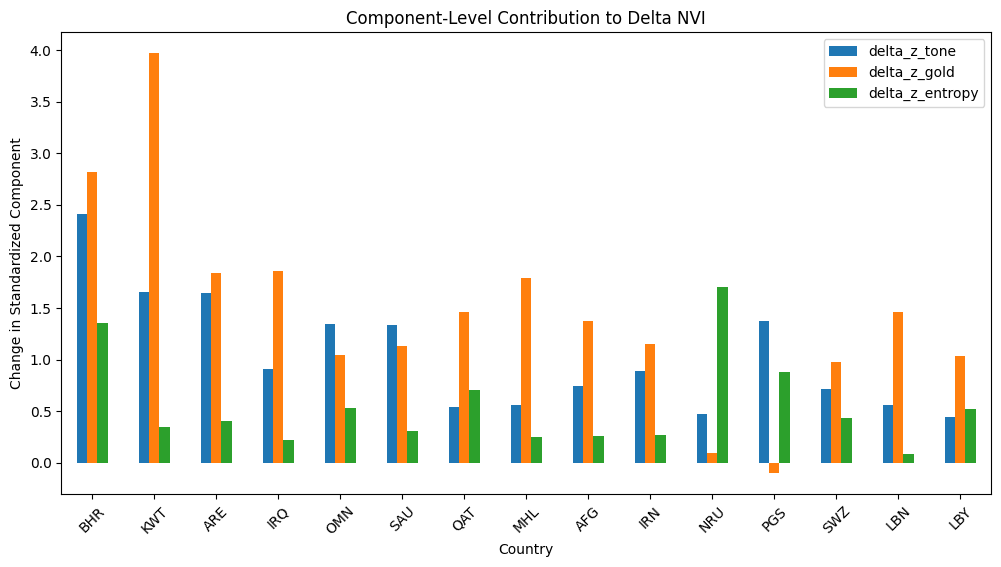

In [74]:
top_delta_components = delta_decomposition.head(15).set_index("country")[
    ["delta_z_tone", "delta_z_gold", "delta_z_entropy"]
]

top_delta_components.plot(kind="bar", figsize=(12, 6))

plt.title("Component-Level Contribution to Delta NVI")
plt.xlabel("Country")
plt.ylabel("Change in Standardized Component")
plt.xticks(rotation=45)
plt.show()

The component-level decomposition shows that the largest positive NVI shifts are mainly driven by increases in **Goldstein volatility** and **tone volatility**.

For several Gulf countries, including **BHR**, **KWT**, **ARE**, and **QAT**, the dominant increase comes from **Goldstein volatility**. This suggests stronger fluctuation in cooperation-conflict signals between 2025 and early 2026.

For **OMN** and **SAU**, the dominant increase is instead associated with **tone volatility**, suggesting stronger changes in the emotional tone of media narratives.

Overall, the 2026 increase is not driven by a single component for all countries. However, the results indicate that **Goldstein volatility plays a central role in the largest Gulf-related NVI shifts**.

### 11.5 Direction of Narrative Change: Tone, Goldstein, and Entropy Levels

The NVI measures **volatility**, but it does not directly show whether the narrative became more negative, more positive, more conflict-oriented, or more cooperation-oriented.

Therefore, this section compares the average levels of tone, Goldstein score, and entropy between the 2025 baseline period and early 2026.

- `delta_tone_level` shows whether the average media tone became more positive or more negative.
- `delta_goldstein_level` shows whether the average event signal became more cooperation-oriented or more conflict-oriented.
- `delta_entropy_level` shows whether the diversity of broad event classes increased or decreased.

This helps distinguish **how much the narrative changed** from **what direction the narrative moved in**.

In [75]:
# Remove old level columns if this cell is re-run
level_cols = [
    "tone_level_2025", "goldstein_level_2025", "entropy_level_2025",
    "event_count_2025",
    "tone_level_2026", "goldstein_level_2026", "entropy_level_2026",
    "event_count_2026",
    "delta_tone_level", "delta_goldstein_level", "delta_entropy_level"
]

merged = merged.drop(columns=[col for col in level_cols if col in merged.columns], errors="ignore")

# Average narrative levels for the 2025 baseline period
levels_2025 = con.execute("""
SELECT
    country,
    AVG(tone_mean) AS tone_level_2025,
    AVG(goldstein_mean) AS goldstein_level_2025,
    AVG(quad_entropy) AS entropy_level_2025,
    SUM(event_count) AS event_count_2025
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-01'
GROUP BY country
""").fetchdf()

# Average narrative levels for early 2026
levels_2026 = con.execute("""
SELECT
    country,
    AVG(tone_mean) AS tone_level_2026,
    AVG(goldstein_mean) AS goldstein_level_2026,
    AVG(quad_entropy) AS entropy_level_2026,
    SUM(event_count) AS event_count_2026
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2026-01-01' AND DATE '2026-03-01'
GROUP BY country
""").fetchdf()

# Merge level indicators into the validation dataframe
merged = merged.merge(levels_2025, on="country", how="left")
merged = merged.merge(levels_2026, on="country", how="left")

# Compute directional changes
merged["delta_tone_level"] = merged["tone_level_2026"] - merged["tone_level_2025"]
merged["delta_goldstein_level"] = merged["goldstein_level_2026"] - merged["goldstein_level_2025"]
merged["delta_entropy_level"] = merged["entropy_level_2026"] - merged["entropy_level_2025"]

directional_change_table = merged[[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "tone_level_2025",
    "tone_level_2026",
    "delta_tone_level",
    "goldstein_level_2025",
    "goldstein_level_2026",
    "delta_goldstein_level",
    "entropy_level_2025",
    "entropy_level_2026",
    "delta_entropy_level",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

directional_change_table.head(20)

,country,NVI_2025,NVI_2026,delta_NVI,tone_level_2025,tone_level_2026,delta_tone_level,goldstein_level_2025,goldstein_level_2026,delta_goldstein_level,entropy_level_2025,entropy_level_2026,delta_entropy_level,regime_2025,regime_2026
92,BHR,-0.513215,6.067970,6.581186,1.517864,-0.841246,-2.359110,2.433867,0.677837,-1.756030,0.654682,0.869868,0.215186,Moderate,Shock
96,KWT,-0.238648,5.732120,5.970768,0.825767,-1.367128,-2.192895,1.890013,-0.246263,-2.136276,0.856158,0.983671,0.127512,Moderate,Shock
33,ARE,-1.235715,2.645284,3.880999,0.440653,-1.243646,-1.684299,1.920277,1.037299,-0.882978,0.854582,0.908598,0.054016,Moderate,Shock
204,IRQ,-2.688478,0.302389,2.990867,-2.242535,-3.604403,-1.361868,0.315767,-0.857549,-1.173316,1.103491,1.170110,0.066619,Stable,Moderate
107,OMN,0.723203,3.646784,2.923581,1.345288,-1.354022,-2.699310,2.493304,1.959596,-0.533708,0.699919,0.719494,0.019575,Moderate,Shock
101,SAU,-1.831909,0.949078,2.780987,-0.483584,-1.748273,-1.264689,1.851779,0.992895,-0.858884,0.815629,0.976097,0.160468,Stable,Moderate
138,QAT,0.113307,2.825710,2.712403,-1.307737,-2.113119,-0.805382,2.047111,0.995551,-1.051560,0.811205,0.944582,0.133377,Moderate,Shock
135,MHL,3.299954,5.893928,2.593974,-0.231242,-1.018433,-0.787191,1.714399,0.447147,-1.267252,0.776061,0.997110,0.221049,Shock,Shock
44,AFG,-1.269015,1.112376,2.381391,-3.476951,-4.672087,-1.195136,0.244937,-1.186147,-1.431084,1.139288,1.225289,0.086001,Moderate,Shock
161,IRN,-1.395491,0.910231,2.305722,-3.283432,-4.359471,-1.076039,0.291502,-0.963410,-1.254912,1.099542,1.172947,0.073405,Moderate,Moderate


The directional table adds an important interpretation layer to the NVI results. Countries with large positive `delta_NVI` experienced stronger narrative volatility in early 2026, but the tone and Goldstein deltas indicate whether this volatility was associated with more negative or more conflict-oriented narratives.

A positive `delta_tone_level` means that average tone became more positive, while a negative value means that average tone became more negative. A positive `delta_goldstein_level` suggests a more cooperation-oriented average event signal, while a negative value suggests a more conflict-oriented average event signal.

This distinction is important because a country can become more volatile without necessarily becoming more negative or more conflict-oriented on average.

The directional results show that many of the largest positive `delta_NVI` cases also experienced a decline in average tone. This is especially visible among Gulf countries such as **BHR**, **KWT**, **ARE**, **OMN**, **SAU**, and **QAT**. In these cases, the NVI increase is not only a volatility signal; it is also accompanied by a shift toward a more negative average media tone.

The Goldstein direction is also important. Several of the same countries show decreases in average Goldstein score, which suggests that the average event signal became less cooperation-oriented or more conflict-oriented in early 2026.

Therefore, the early-2026 Gulf pattern can be interpreted as a combined shift: **higher narrative volatility**, **more negative average tone**, and in several cases a **less cooperation-oriented event profile**.

### 11.6 Conflict-Context Interpretation

The largest positive NVI shifts are concentrated in several **Gulf countries**, including **Bahrain**, **Kuwait**, the **United Arab Emirates**, **Oman**, **Saudi Arabia**, and **Qatar**. This pattern is important because the early-2026 period overlaps with a major escalation involving Iran, Israel, and Gulf countries.

External conflict reporting from **ACLED** describes that, during March 2026, Iran attacked all Gulf Cooperation Council countries for the first time, including Bahrain, Kuwait, Oman, Qatar, Saudi Arabia, and the UAE (ACLED, 2026a). ACLED’s April 2026 Middle East overview also reports later escalation affecting Gulf industrial and energy-related targets, including facilities in Bahrain and the UAE (ACLED, 2026b).

Therefore, the increase in NVI among Gulf countries can be interpreted as **descriptively consistent** with regional escalation during early 2026. However, this should **not** be treated as causal proof. The NVI measures changes in **narrative volatility**, not the direct physical impact or severity of conflict.

## 12. War-Relevant Regional Group Comparison

To interpret the 2025–2026 changes more clearly, countries are grouped into selected conflict-relevant regional sets. These groups are not formal statistical clusters; they are used for descriptive comparison.

The purpose is to examine whether countries directly or indirectly connected to major conflict environments show different NVI shifts.

In [76]:
war_group_map = {
    # Gulf countries affected by Iran-Gulf escalation
    "BHR": "Gulf",
    "KWT": "Gulf",
    "ARE": "Gulf",
    "OMN": "Gulf",
    "SAU": "Gulf",
    "QAT": "Gulf",

    # Iran-Israel core comparison
    "IRN": "Iran-Israel Core",
    "ISR": "Iran-Israel Core",

    # Levant / Gaza-related regional environment
    "PSE": "Levant / Gaza-related",
    "LBN": "Levant / Gaza-related",
    "SYR": "Levant / Gaza-related",
    "JOR": "Levant / Gaza-related",
    "IRQ": "Levant / Gaza-related",
    "YEM": "Levant / Gaza-related",

    # Ukraine-Russia war environment
    "UKR": "Ukraine-Russia",
    "RUS": "Ukraine-Russia",

    # Selected Africa conflict cases
    "SDN": "Africa conflict cases",
    "SSD": "Africa conflict cases",
    "TCD": "Africa conflict cases",
    "COD": "Africa conflict cases",
    "NGA": "Africa conflict cases",
    "MLI": "Africa conflict cases",
    "NER": "Africa conflict cases",
    "BFA": "Africa conflict cases"
}

merged["war_relevant_group"] = merged["country"].map(war_group_map).fillna("Other")

### 12.1 Group-Level Delta Summary

This section summarizes how NVI changed across selected conflict-relevant country groups.

The goal is to compare whether countries connected to specific conflict environments show different levels of change in narrative volatility between 2025 and early 2026. The comparison is descriptive and should not be interpreted as causal evidence.

In [77]:
# Create transition flags before group-level aggregation
merged["moved_to_shock_flag"] = (
    (merged["regime_2025"] != "Shock") & 
    (merged["regime_2026"] == "Shock")
)

merged["shock_2026_flag"] = merged["regime_2026"] == "Shock"

# Group-level summary
war_group_summary = merged.groupby("war_relevant_group").agg(
    country_count=("country", "count"),
    mean_delta_NVI=("delta_NVI", "mean"),
    median_delta_NVI=("delta_NVI", "median"),
    max_delta_NVI=("delta_NVI", "max"),
    shock_2026_count=("shock_2026_flag", "sum"),
    moved_to_shock=("moved_to_shock_flag", "sum")
).reset_index()

war_group_summary = war_group_summary.sort_values("mean_delta_NVI", ascending=False)

war_group_summary

,war_relevant_group,country_count,mean_delta_NVI,median_delta_NVI,max_delta_NVI,shock_2026_count,moved_to_shock
1,Gulf,6,4.141654,3.402290,6.581186,5,5
2,Iran-Israel Core,2,1.741932,1.741932,2.305722,0,0
3,Levant / Gaza-related,6,1.032664,0.520649,2.990867,0,0
4,Other,187,0.086349,0.038867,2.593974,57,8
0,Africa conflict cases,8,0.049366,0.230921,1.614415,1,1
5,Ukraine-Russia,2,-0.404406,-0.404406,-0.233592,0,0


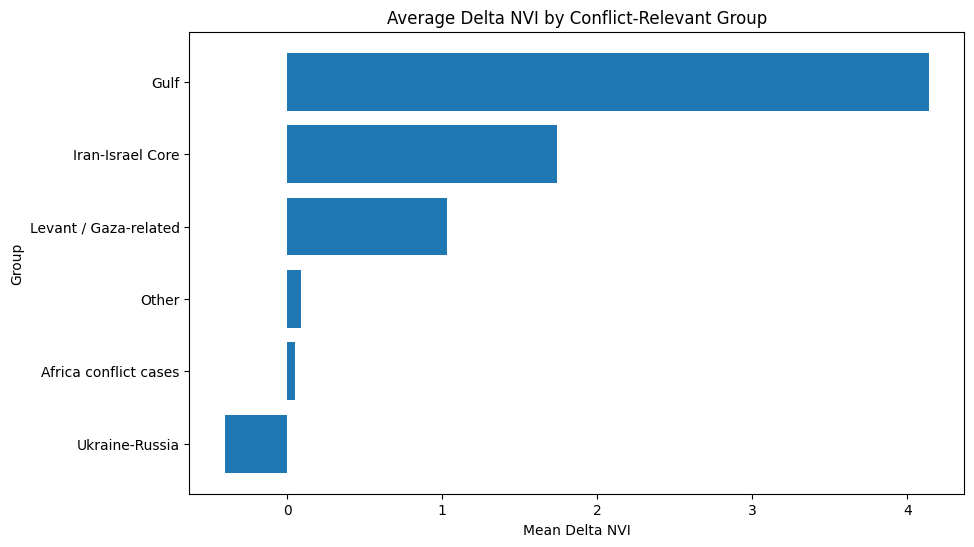

In [78]:
# Plot including all groups
plot_df = war_group_summary.sort_values("mean_delta_NVI", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["war_relevant_group"], plot_df["mean_delta_NVI"])

plt.title("Average Delta NVI by Conflict-Relevant Group")
plt.xlabel("Mean Delta NVI")
plt.ylabel("Group")
plt.show()

The group-level results show that the **Gulf group has by far the highest mean delta NVI**. Its average increase is substantially larger than the Iran-Israel Core, Levant/Gaza-related countries, Africa conflict cases, and the Ukraine-Russia group.

This is one of the strongest findings of the out-of-sample validation. It suggests that the 2026 increase in narrative volatility is especially concentrated among **Gulf countries**.

The **Iran-Israel Core** and **Levant/Gaza-related** groups also show positive average changes, but their increases are smaller than the Gulf group. The **Ukraine-Russia** group shows a negative mean delta NVI in this sample, suggesting that narrative volatility did not increase relative to the 2025 baseline under this framework.

The `Other` group is included as a broad reference category, but it should not be interpreted as a conflict-relevant group. It contains a large and heterogeneous set of countries that are not part of the selected conflict-focused groups.

These results should be interpreted **descriptively**. Group averages may be affected by the small number of countries in each group, differences in event coverage, and the fact that the 2026 data covers only the early part of the year.

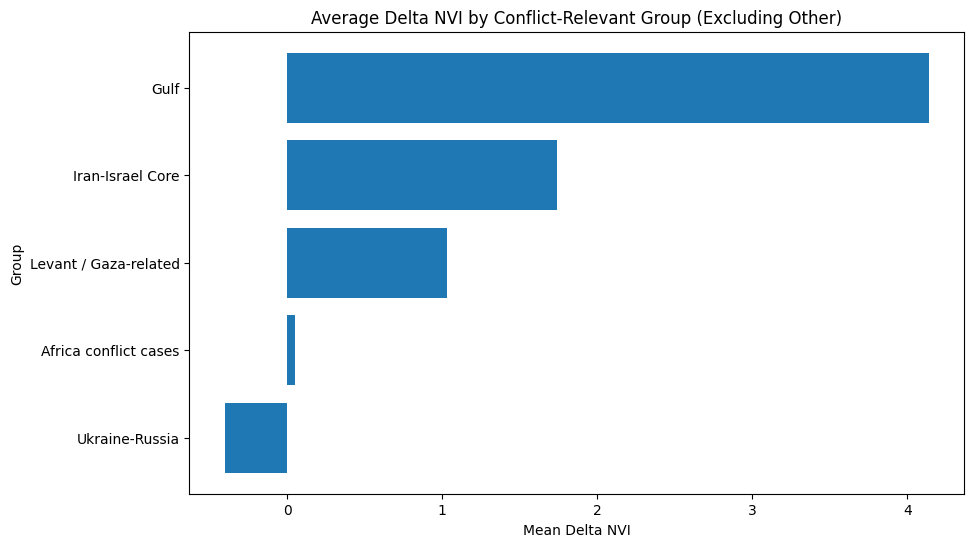

In [79]:
# Plot excluding the broad "Other" category
plot_df_no_other = war_group_summary[
    war_group_summary["war_relevant_group"] != "Other"
].sort_values("mean_delta_NVI", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df_no_other["war_relevant_group"],
    plot_df_no_other["mean_delta_NVI"]
)

plt.title("Average Delta NVI by Conflict-Relevant Group (Excluding Other)")
plt.xlabel("Mean Delta NVI")
plt.ylabel("Group")
plt.show()

The same comparison is also shown without the broad `Other` category, because this group contains a large and heterogeneous set of countries. Excluding it makes the selected conflict-relevant groups easier to compare.

This second plot makes the contrast clearer: the **Gulf group** shows the strongest increase in average NVI, while the **Iran-Israel Core** and **Levant/Gaza-related** groups show more moderate positive changes. The **Ukraine-Russia** group shows a negative average delta NVI in this sample.

This does not mean that the Ukraine-Russia war became unimportant. Rather, it means that under this NVI framework and the available early-2026 data, the selected narrative volatility indicators did not increase relative to the 2025 baseline for that group.

### 12.2 Gulf Countries: Focused Interpretation

The Gulf countries show the strongest positive NVI shifts in the current results. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show increases in NVI from 2025 to 2026, with several countries moving into the **Shock** regime.

This is one of the clearest findings of the out-of-sample validation notebook.

In [80]:
gulf_countries = ["BHR", "KWT", "ARE", "OMN", "SAU", "QAT"]

gulf_table = merged[merged["country"].isin(gulf_countries)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy",
    "tone_level_2025",
    "tone_level_2026",
    "delta_tone_level",
    "goldstein_level_2025",
    "goldstein_level_2026",
    "delta_goldstein_level",
    "entropy_level_2025",
    "entropy_level_2026",
    "delta_entropy_level",
    "dominant_delta_component",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

gulf_table

,country,NVI_2025,NVI_2026,delta_NVI,delta_z_tone,delta_z_gold,delta_z_entropy,tone_level_2025,tone_level_2026,delta_tone_level,goldstein_level_2025,goldstein_level_2026,delta_goldstein_level,entropy_level_2025,entropy_level_2026,delta_entropy_level,dominant_delta_component,regime_2025,regime_2026
92,BHR,-0.513215,6.067970,6.581186,2.407456,2.821071,1.352659,1.517864,-0.841246,-2.359110,2.433867,0.677837,-1.756030,0.654682,0.869868,0.215186,delta_z_gold,Moderate,Shock
96,KWT,-0.238648,5.732120,5.970768,1.651851,3.968646,0.350270,0.825767,-1.367128,-2.192895,1.890013,-0.246263,-2.136276,0.856158,0.983671,0.127512,delta_z_gold,Moderate,Shock
33,ARE,-1.235715,2.645284,3.880999,1.641838,1.837744,0.401416,0.440653,-1.243646,-1.684299,1.920277,1.037299,-0.882978,0.854582,0.908598,0.054016,delta_z_gold,Moderate,Shock
107,OMN,0.723203,3.646784,2.923581,1.346600,1.043425,0.533556,1.345288,-1.354022,-2.699310,2.493304,1.959596,-0.533708,0.699919,0.719494,0.019575,delta_z_tone,Moderate,Shock
101,SAU,-1.831909,0.949078,2.780987,1.333853,1.135778,0.311357,-0.483584,-1.748273,-1.264689,1.851779,0.992895,-0.858884,0.815629,0.976097,0.160468,delta_z_tone,Stable,Moderate
138,QAT,0.113307,2.825710,2.712403,0.543367,1.465321,0.703715,-1.307737,-2.113119,-0.805382,2.047111,0.995551,-1.051560,0.811205,0.944582,0.133377,delta_z_gold,Moderate,Shock


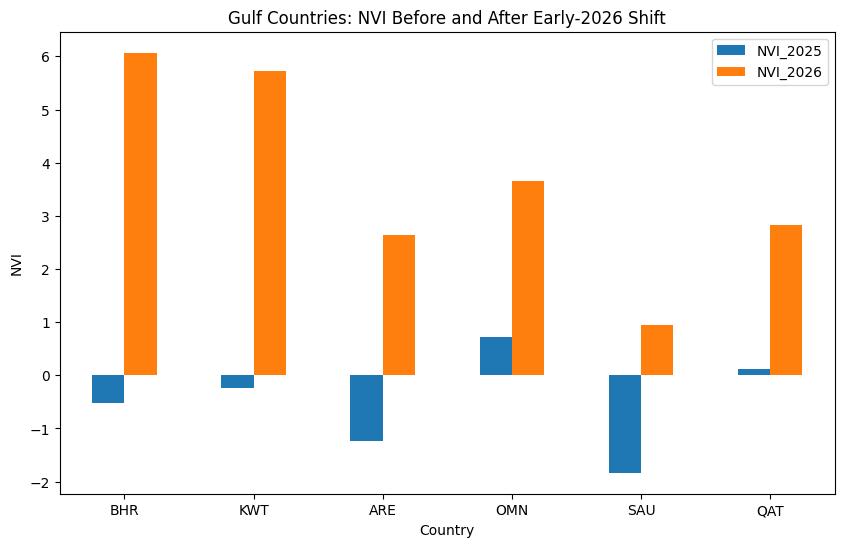

In [81]:
gulf_plot = gulf_table.sort_values("delta_NVI", ascending=False).set_index("country")

gulf_plot[["NVI_2025", "NVI_2026"]].plot(kind="bar", figsize=(10, 6))

plt.title("Gulf Countries: NVI Before and After Early-2026 Shift")
plt.xlabel("Country")
plt.ylabel("NVI")
plt.xticks(rotation=0)
plt.show()

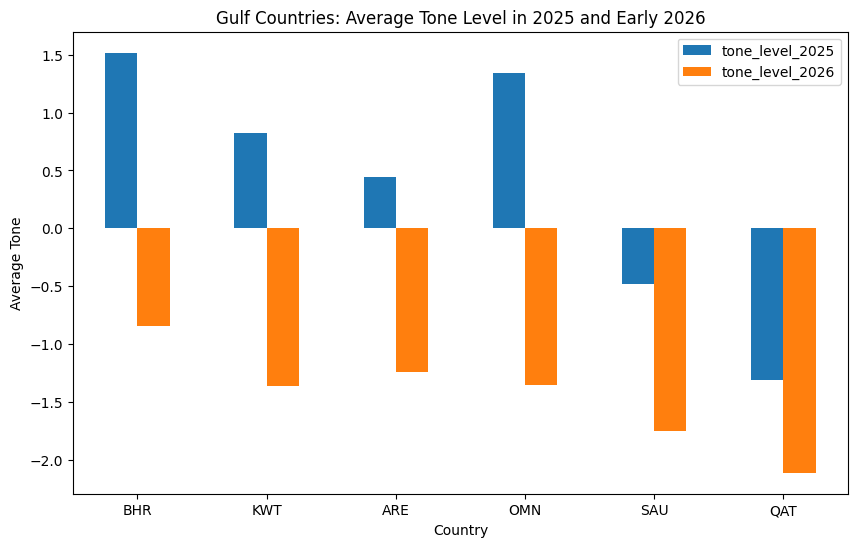

In [82]:
gulf_plot[["tone_level_2025", "tone_level_2026"]].plot(kind="bar", figsize=(10, 6))

plt.title("Gulf Countries: Average Tone Level in 2025 and Early 2026")
plt.xlabel("Country")
plt.ylabel("Average Tone")
plt.xticks(rotation=0)
plt.show()

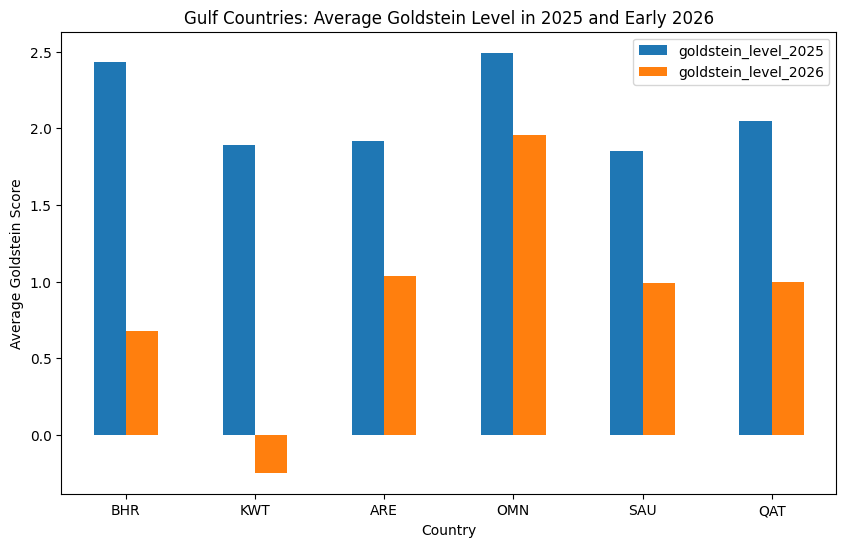

In [83]:
gulf_plot[["goldstein_level_2025", "goldstein_level_2026"]].plot(kind="bar", figsize=(10, 6))

plt.title("Gulf Countries: Average Goldstein Level in 2025 and Early 2026")
plt.xlabel("Country")
plt.ylabel("Average Goldstein Score")
plt.xticks(rotation=0)
plt.show()

The Gulf-focused table confirms that all six Gulf countries in the selected group experienced **positive delta NVI** values. This means that narrative volatility increased in early 2026 when evaluated against the 2025 baseline.

Five of the six countries, **BHR**, **KWT**, **ARE**, **OMN**, and **QAT**, move into the **Shock** regime in 2026. **SAU** also shows a strong positive increase but moves from `Stable` to `Moderate` rather than `Shock`.

The component decomposition shows that the increases are mainly associated with **Goldstein volatility** for **BHR**, **KWT**, **ARE**, and **QAT**, while **tone volatility** is dominant for **OMN** and **SAU**.

The level indicators add an important directional interpretation. All six Gulf countries show a decline in average tone from 2025 to early 2026, meaning that the increase in NVI is also accompanied by a shift toward a more negative media tone. Several Gulf countries also show decreases in average Goldstein score, suggesting a less cooperation-oriented or more conflict-oriented event profile.

Overall, the Gulf group is the clearest regional signal **within the selected conflict-relevant groups** in this out-of-sample validation notebook.

In [84]:
import geopandas as gpd
import zipfile
import tempfile
import matplotlib.pyplot as plt

# Load country shapefile from local Natural Earth zip file
zip_path = "../data/external/ne_110m_admin_0_countries.zip"

with zipfile.ZipFile(zip_path) as z:
    shp_file = [f for f in z.namelist() if f.endswith(".shp")][0]
    with tempfile.TemporaryDirectory() as tmpdir:
        z.extractall(tmpdir)
        world = gpd.read_file(f"{tmpdir}/{shp_file}")

# Check available ISO column names
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [85]:
# Detect ISO-3 country code column
if "ISO_A3" in world.columns:
    iso_col = "ISO_A3"
elif "iso_a3" in world.columns:
    iso_col = "iso_a3"
elif "ADM0_A3" in world.columns:
    iso_col = "ADM0_A3"
else:
    raise ValueError("No ISO-3 country code column found in the shapefile.")

# Gulf countries should match ISO-3 codes such as BHR, KWT, ARE, OMN, SAU, QAT
gulf_map = world.merge(
    gulf_table[[
        "country",
        "delta_NVI",
        "NVI_2025",
        "NVI_2026",
        "regime_2026"
    ]],
    left_on=iso_col,
    right_on="country",
    how="inner"
)

gulf_map[["country", "delta_NVI", "NVI_2025", "NVI_2026", "regime_2026"]]

,country,delta_NVI,NVI_2025,NVI_2026,regime_2026
0,ARE,3.880999,-1.235715,2.645284,Shock
1,QAT,2.712403,0.113307,2.825710,Shock
2,KWT,5.970768,-0.238648,5.732120,Shock
3,OMN,2.923581,0.723203,3.646784,Shock
4,SAU,2.780987,-1.831909,0.949078,Moderate


In [86]:
from matplotlib import cm

def add_country_labels_and_bhr_marker(ax, gulf_map, gulf_table, value_col, cmap_name, norm):
    # Existing country labels from shapefile
    for _, row in gulf_map.iterrows():
        point = row.geometry.representative_point()
        ax.text(
            point.x,
            point.y,
            row["country"],
            fontsize=9,
            ha="center"
        )
    
    # Add Bahrain manually if it is not matched in the shapefile
    if "BHR" not in gulf_map["country"].values and "BHR" in gulf_table["country"].values:
        bhr_row = gulf_table[gulf_table["country"] == "BHR"].iloc[0]
        
        bhr_lon = 50.55
        bhr_lat = 26.07
        
        cmap = cm.get_cmap(cmap_name)
        bhr_color = cmap(norm(bhr_row[value_col]))
        
        ax.scatter(
            bhr_lon,
            bhr_lat,
            s=120,
            color=bhr_color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5
        )
        
        ax.text(
            bhr_lon,
            bhr_lat + 0.7,
            "BHR",
            fontsize=9,
            ha="center",
            fontweight="bold"
        )

In [87]:
from matplotlib.colors import TwoSlopeNorm

delta_abs_max = max(
    abs(gulf_table["delta_NVI"].min()),
    abs(gulf_table["delta_NVI"].max())
)

delta_norm = TwoSlopeNorm(
    vmin=-delta_abs_max,
    vcenter=0,
    vmax=delta_abs_max
)

/tmp/ipykernel_5594/755051201.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


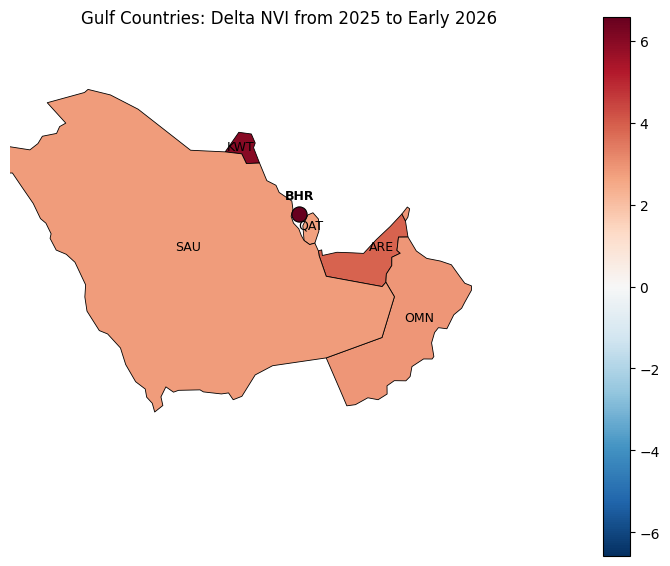

In [88]:
fig, ax = plt.subplots(figsize=(9, 7))

gulf_map.plot(
    column="delta_NVI",
    cmap="RdBu_r",
    legend=True,
    norm=delta_norm,
    edgecolor="black",
    linewidth=0.6,
    ax=ax
)

ax.set_xlim(35, 65)
ax.set_ylim(10, 35)

add_country_labels_and_bhr_marker(
    ax=ax,
    gulf_map=gulf_map,
    gulf_table=gulf_table,
    value_col="delta_NVI",
    cmap_name="RdBu_r",
    norm=delta_norm
)

ax.set_title("Gulf Countries: Delta NVI from 2025 to Early 2026")
ax.axis("off")
plt.show()

In [89]:
from matplotlib.colors import Normalize

nvi_min = min(gulf_map["NVI_2025"].min(), gulf_map["NVI_2026"].min(), gulf_table["NVI_2025"].min(), gulf_table["NVI_2026"].min())
nvi_max = max(gulf_map["NVI_2025"].max(), gulf_map["NVI_2026"].max(), gulf_table["NVI_2025"].max(), gulf_table["NVI_2026"].max())

nvi_norm = Normalize(vmin=nvi_min, vmax=nvi_max)

/tmp/ipykernel_5594/755051201.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


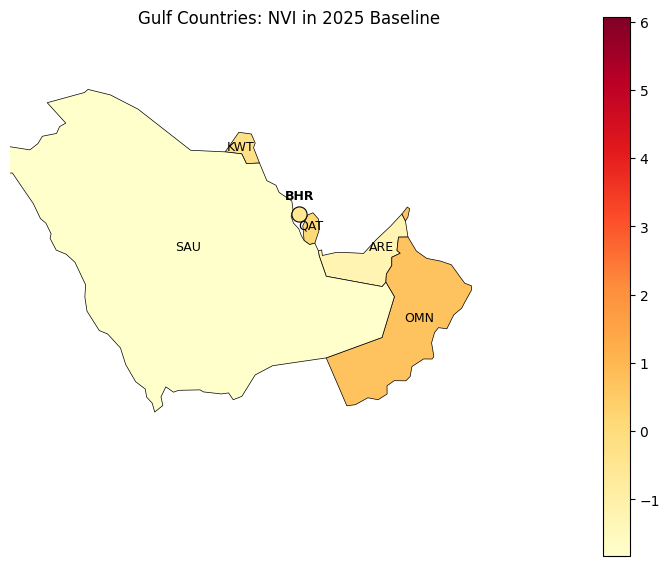

In [90]:
fig, ax = plt.subplots(figsize=(9, 7))

gulf_map.plot(
    column="NVI_2025",
    cmap="YlOrRd",
    legend=True,
    vmin=nvi_min,
    vmax=nvi_max,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_xlim(35, 65)
ax.set_ylim(10, 35)

add_country_labels_and_bhr_marker(
    ax=ax,
    gulf_map=gulf_map,
    gulf_table=gulf_table,
    value_col="NVI_2025",
    cmap_name="YlOrRd",
    norm=nvi_norm
)

ax.set_title("Gulf Countries: NVI in 2025 Baseline")
ax.axis("off")
plt.show()

/tmp/ipykernel_5594/755051201.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


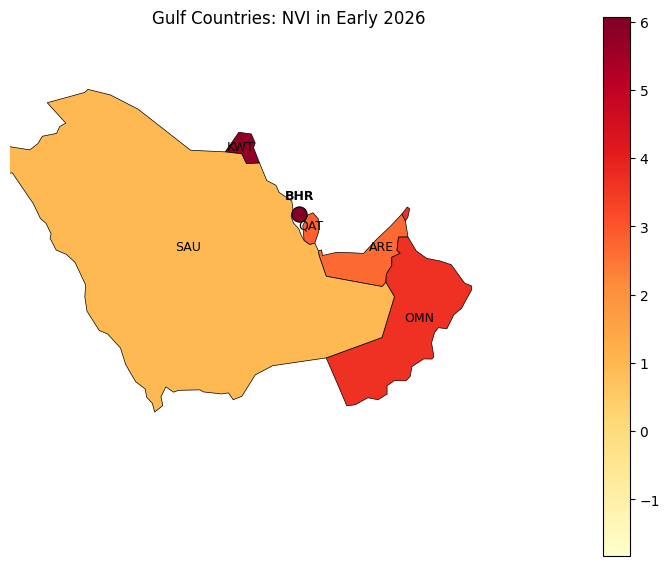

In [91]:
fig, ax = plt.subplots(figsize=(9, 7))

gulf_map.plot(
    column="NVI_2026",
    cmap="YlOrRd",
    legend=True,
    vmin=nvi_min,
    vmax=nvi_max,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_xlim(35, 65)
ax.set_ylim(10, 35)

add_country_labels_and_bhr_marker(
    ax=ax,
    gulf_map=gulf_map,
    gulf_table=gulf_table,
    value_col="NVI_2026",
    cmap_name="YlOrRd",
    norm=nvi_norm
)

ax.set_title("Gulf Countries: NVI in Early 2026")
ax.axis("off")
plt.show()

The Gulf visualizations reinforce the tabular results. The before-and-after NVI bar chart shows that all Gulf countries experienced an increase in NVI from 2025 to early 2026. The tone chart shows that this increase is accompanied by a decline in average tone across all six Gulf countries, indicating a more negative media narrative. The Goldstein chart shows that several countries also shifted toward lower Goldstein scores, suggesting a less cooperation-oriented event profile.

The maps provide the geographic view of this pattern. The 2025 and early-2026 NVI maps use the **same color scale**, so their colors are directly comparable. The early-2026 map shows a stronger NVI intensity across the Gulf region, while the `delta_NVI` map summarizes the increase directly using a separate zero-centered color scale.

Together, the table, bar charts, and maps show that the Gulf result is not only a statistical increase in NVI. It is also a geographically concentrated and directionally meaningful shift in the underlying narrative indicators.

Bahrain (**BHR**) is added as a point marker because it is not matched as a polygon in the Natural Earth 110m shapefile used in this notebook. This can happen for very small island countries at low map resolution. The marker color is scaled using the same colormap and normalization as the corresponding map, so BHR remains visually comparable with the polygon-based countries.

The tabular results remain the primary source for exact NVI values, while the map provides geographic context.

### 12.3 Iran–Israel and Levant Comparison

This comparison examines whether the Iran-Israel core and surrounding Levant/Gaza-related countries show similar or different NVI shifts.

In [92]:
levant_group = [
    "IRN", "ISR", "PSE", "LBN", "SYR", "JOR", "IRQ", "YEM"
]

levant_table = merged[merged["country"].isin(levant_group)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "tone_level_2025",
    "tone_level_2026",
    "delta_tone_level",
    "goldstein_level_2025",
    "goldstein_level_2026",
    "delta_goldstein_level",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

levant_table

,country,NVI_2025,NVI_2026,delta_NVI,tone_level_2025,tone_level_2026,delta_tone_level,goldstein_level_2025,goldstein_level_2026,delta_goldstein_level,regime_2025,regime_2026
204,IRQ,-2.688478,0.302389,2.990867,-2.242535,-3.604403,-1.361868,0.315767,-0.857549,-1.173316,Stable,Moderate
161,IRN,-1.395491,0.910231,2.305722,-3.283432,-4.359471,-1.076039,0.291502,-0.963410,-1.254912,Moderate,Moderate
103,LBN,-2.167016,-0.059593,2.107423,-3.385661,-3.975786,-0.590125,0.106292,-0.956747,-1.063039,Stable,Moderate
131,ISR,-2.531581,-1.353440,1.178141,-4.415823,-3.882107,0.533716,-0.958725,-1.332914,-0.374189,Stable,Moderate
169,PSE,-2.401550,-1.669835,0.731715,-4.760854,-4.419353,0.341501,-0.859738,-1.449084,-0.589346,Stable,Moderate
122,YEM,-0.618503,-0.308921,0.309582,-3.928813,-3.328086,0.600727,-1.649529,-0.515086,1.134443,Moderate,Moderate
80,JOR,-1.754275,-1.585589,0.168687,-1.826459,-1.637247,0.189212,0.683169,0.507042,-0.176128,Stable,Moderate
120,SYR,-0.006359,-0.118648,-0.112289,-3.156474,-3.038316,0.118159,0.297349,-0.215724,-0.513073,Moderate,Moderate


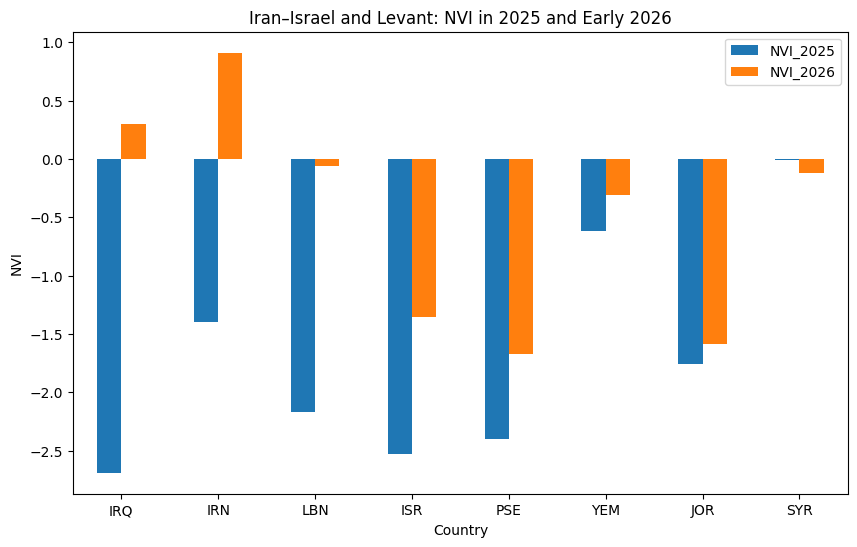

In [93]:
levant_plot = levant_table.sort_values("delta_NVI", ascending=False).set_index("country")

levant_plot[["NVI_2025", "NVI_2026"]].plot(kind="bar", figsize=(10, 6))

plt.title("Iran–Israel and Levant: NVI in 2025 and Early 2026")
plt.xlabel("Country")
plt.ylabel("NVI")
plt.xticks(rotation=0)
plt.show()

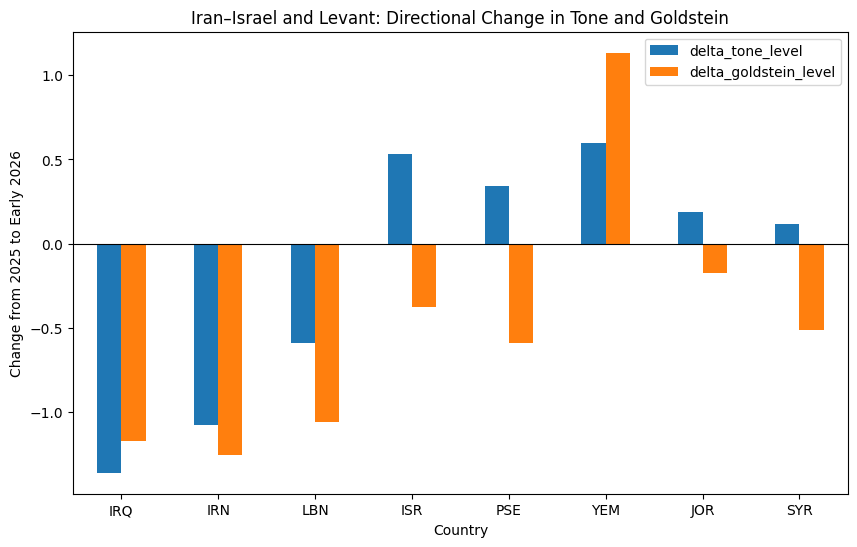

In [94]:
levant_plot[["delta_tone_level", "delta_goldstein_level"]].plot(kind="bar", figsize=(10, 6))

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Iran–Israel and Levant: Directional Change in Tone and Goldstein")
plt.xlabel("Country")
plt.ylabel("Change from 2025 to Early 2026")
plt.xticks(rotation=0)
plt.show()

The NVI comparison shows that most countries in the Iran–Israel and Levant group experienced an increase in narrative volatility from 2025 to early 2026. However, the magnitude of this increase is clearly smaller than the Gulf group, and none of the selected countries move into the **Shock** regime.

The largest NVI increases are observed for **IRQ**, **IRN**, and **LBN**. These countries also show declines in both average tone and average Goldstein score. This suggests that their increase in narrative volatility was accompanied by a more negative and less cooperation-oriented narrative profile.

The directional change chart shows a more mixed pattern for the rest of the group. **ISR**, **PSE**, **YEM**, and **JOR** show smaller positive NVI changes, but their average tone levels become less negative in early 2026. This demonstrates an important interpretation point: an increase in NVI does **not** always mean that the narrative became more negative. It means that the narrative became more volatile.

The Goldstein direction adds another layer. **ISR**, **PSE**, **JOR**, and **SYR** show declining Goldstein levels, suggesting a less cooperation-oriented average event signal, while **YEM** shows an increase in Goldstein score. Therefore, even within the same regional conflict environment, countries differ in both the size and direction of narrative change.

Overall, this section shows that politically central conflict actors do not necessarily produce the largest NVI shifts. The NVI measures **volatility in narrative indicators**, while tone and Goldstein levels help explain the **direction and character** of that volatility.

### 12.4 Africa Conflict Cases

This section checks selected African conflict cases to see whether early 2026 conflict dynamics are reflected in NVI changes.

In [95]:
africa_conflict_cases = ["SDN", "SSD", "TCD", "COD", "NGA", "MLI", "NER", "BFA"]

africa_conflict_table = merged[merged["country"].isin(africa_conflict_cases)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "tone_level_2025",
    "tone_level_2026",
    "delta_tone_level",
    "goldstein_level_2025",
    "goldstein_level_2026",
    "delta_goldstein_level",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

africa_conflict_table

,country,NVI_2025,NVI_2026,delta_NVI,tone_level_2025,tone_level_2026,delta_tone_level,goldstein_level_2025,goldstein_level_2026,delta_goldstein_level,regime_2025,regime_2026
136,MLI,-0.116840,1.497574,1.614415,-3.446760,-2.622175,0.824585,0.180365,0.762075,0.581710,Moderate,Shock
197,NER,-1.277296,0.320319,1.597615,-3.044576,-3.637046,-0.592470,0.238429,-0.724764,-0.963193,Moderate,Moderate
91,BFA,-0.638511,0.373511,1.012022,-2.607910,-3.284795,-0.676885,0.554525,-0.076583,-0.631108,Moderate,Moderate
186,SDN,-2.150241,-1.813403,0.336838,-4.757025,-4.374188,0.382837,-0.920309,-0.705810,0.214499,Stable,Stable
168,NGA,-2.854478,-2.729474,0.125003,-1.270854,-1.642967,-0.372113,0.509457,0.267739,-0.241718,Stable,Stable
30,TCD,-0.956914,-1.654367,-0.697453,-2.667684,-2.902647,-0.234964,0.150032,0.211878,0.061846,Moderate,Moderate
119,SSD,-0.541221,-1.848295,-1.307073,-3.201266,-3.029289,0.171977,0.232812,-0.156564,-0.389376,Moderate,Stable
0,COD,2.293372,0.006936,-2.286435,-3.359478,-2.786391,0.573087,0.589550,0.521657,-0.067893,Shock,Moderate


The selected Africa conflict cases show mixed NVI changes. **MLI**, **NER**, and **BFA** show positive delta NVI values, with **MLI** moving from `Moderate` to `Shock`.

However, the directional indicators show that these increases do not all have the same interpretation. **MLI** shows an increase in NVI, but its average tone and Goldstein score also increase, suggesting that higher volatility is not necessarily associated with a more negative or more conflict-oriented narrative in this case.

By contrast, **NER** and **BFA** show positive NVI changes together with declining tone and Goldstein scores, which suggests a more negative and less cooperation-oriented narrative profile.

Not all selected African conflict cases show increases. **SSD** and **COD** show negative delta NVI values, and **COD** moves from `Shock` to `Moderate`. This suggests that conflict relevance does not automatically translate into higher NVI.

The mixed results indicate that the NVI captures changes in **narrative volatility**, not conflict presence alone. Tone and Goldstein levels are needed to interpret whether that volatility corresponds to a more negative or more conflict-oriented narrative direction.

### 12.5 Special Case: Turkiye

This section examines Türkiye as a selected country case. Turkiye is included as a special case because it is geographically and politically connected to several regional environments considered in this notebook, including The Europe, the Middle East, the Black Sea region, migration routes, and broader regional security dynamics.

The purpose of this section is descriptive. It does not claim that Turkiye’s NVI change is caused by a single event. Instead, it examines whether Turkiye’s narrative volatility, tone, and Goldstein indicators changed from the 2025 baseline to early 2026.

In [96]:
turkiye_case = merged[merged["country"] == "TUR"][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy",
    "tone_level_2025",
    "tone_level_2026",
    "delta_tone_level",
    "goldstein_level_2025",
    "goldstein_level_2026",
    "delta_goldstein_level",
    "entropy_level_2025",
    "entropy_level_2026",
    "delta_entropy_level",
    "dominant_delta_component",
    "regime_2025",
    "regime_2026"
]]

turkiye_case

,country,NVI_2025,NVI_2026,delta_NVI,delta_z_tone,delta_z_gold,delta_z_entropy,tone_level_2025,tone_level_2026,delta_tone_level,goldstein_level_2025,goldstein_level_2026,delta_goldstein_level,entropy_level_2025,entropy_level_2026,delta_entropy_level,dominant_delta_component,regime_2025,regime_2026
70,TUR,-1.025903,-2.24959,-1.223687,-0.23577,-0.415841,-0.572077,-1.83306,-2.148642,-0.315581,1.152501,1.014108,-0.138393,0.966374,0.966664,0.000289,delta_z_tone,Moderate,Stable


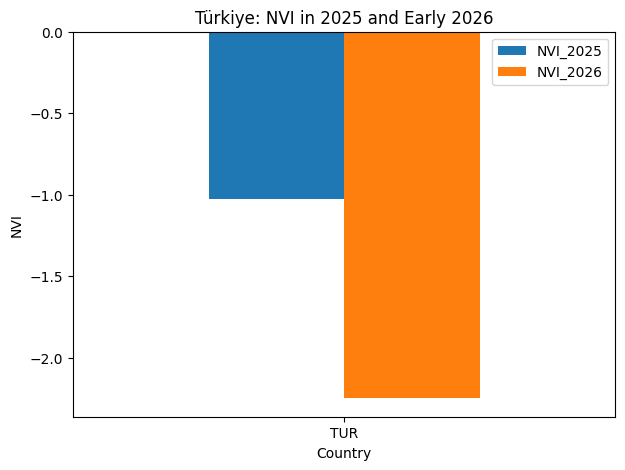

In [97]:
turkiye_plot = turkiye_case.set_index("country")

turkiye_plot[["NVI_2025", "NVI_2026"]].plot(kind="bar", figsize=(7, 5))

plt.title("Türkiye: NVI in 2025 and Early 2026")
plt.xlabel("Country")
plt.ylabel("NVI")
plt.xticks(rotation=0)
plt.show()

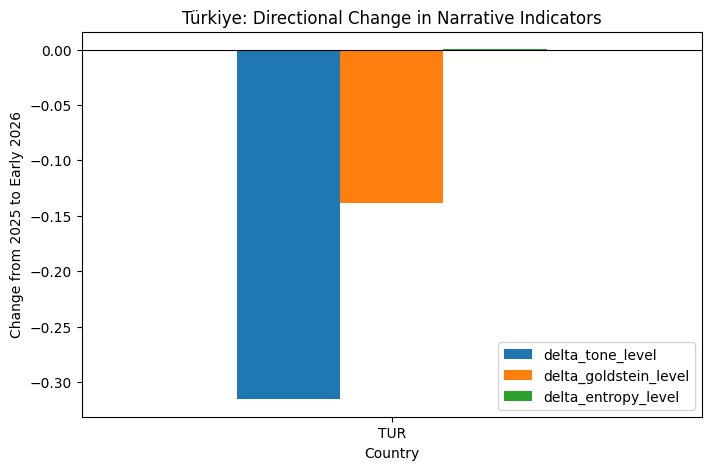

In [98]:
turkiye_plot[[
    "delta_tone_level",
    "delta_goldstein_level",
    "delta_entropy_level"
]].plot(kind="bar", figsize=(8, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Türkiye: Directional Change in Narrative Indicators")
plt.xlabel("Country")
plt.ylabel("Change from 2025 to Early 2026")
plt.xticks(rotation=0)
plt.show()

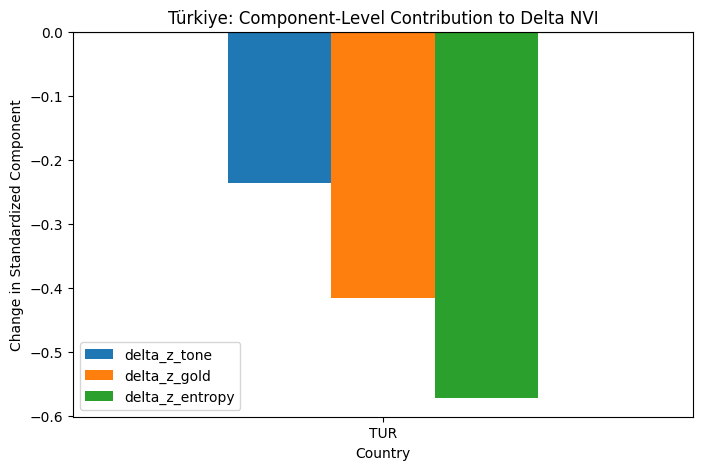

In [99]:
turkiye_plot[[
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy"
]].plot(kind="bar", figsize=(8, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Türkiye: Component-Level Contribution to Delta NVI")
plt.xlabel("Country")
plt.ylabel("Change in Standardized Component")
plt.xticks(rotation=0)
plt.show()

The Türkiye case shows a different pattern from the Gulf-focused results. Türkiye's NVI decreases from **-1.03 in 2025** to **-2.25 in early 2026**, producing a negative `delta_NVI` of approximately **-1.22**. This means that Türkiye's narrative volatility decreased relative to the 2025 baseline.

This change is also reflected in the regime transition: Türkiye moves from **Moderate** in 2025 to **Stable** in early 2026. In the NVI framework, this suggests that Türkiye's selected narrative indicators became more stable over the observed period.

However, the directional indicators add an important nuance. Türkiye's average tone decreases from approximately **-1.83** to **-2.15**, indicating that the media narrative became somewhat more negative on average. The average Goldstein score also decreases slightly from approximately **1.15** to **1.01**, suggesting a modest shift toward a less cooperation-oriented event profile.

Therefore, Türkiye should not be interpreted as having a more positive narrative in early 2026. Instead, the result suggests a **more stable but slightly more negative** narrative profile. This reinforces the main interpretation rule of the notebook: **NVI measures volatility, while tone and Goldstein levels help explain the direction and character of the narrative**.

The component-level chart shows that all three standardized volatility components decrease, with the largest contribution coming from **entropy volatility**, followed by **Goldstein volatility** and **tone volatility**. This indicates that Türkiye's lower NVI in early 2026 is mainly associated with a more stable event-class structure, while cooperation-conflict volatility and media-tone volatility also decrease.

In short, Türkiye's early-2026 profile can be interpreted as **less volatile overall**, but **not more positive**. The narrative became more stable, while average tone and Goldstein levels moved slightly downward.

### 12.6 Countries with the Largest Tone Deterioration and Improvement

This section examines the countries with the largest changes in average tone between the 2025 baseline and early 2026.

Unlike the previous NVI-focused sections, this analysis focuses on the **direction** of the media narrative. A negative `delta_tone_level` indicates that the average media tone became more negative, while a positive value indicates that the average media tone became more positive.

This helps distinguish changes in **narrative volatility** from changes in **narrative direction**.

In [101]:
most_negative_tone_shift = merged[[
    "country",
    "delta_tone_level",
    "tone_level_2025",
    "tone_level_2026",
    "delta_NVI",
    "NVI_2025",
    "NVI_2026",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_tone_level", ascending=True).head(20)

most_negative_tone_shift

,country,delta_tone_level,tone_level_2025,tone_level_2026,delta_NVI,NVI_2025,NVI_2026,regime_2025,regime_2026
107,OMN,-2.699310,1.345288,-1.354022,2.923581,0.723203,3.646784,Moderate,Shock
15,PGS,-2.412006,-0.040791,-2.452797,2.150248,3.457839,5.608087,Shock,Shock
92,BHR,-2.359110,1.517864,-0.841246,6.581186,-0.513215,6.067970,Moderate,Shock
96,KWT,-2.192895,0.825767,-1.367128,5.970768,-0.238648,5.732120,Moderate,Shock
14,GNB,-1.937383,-0.190390,-2.127773,-0.522793,9.053513,8.530720,Shock,Shock
121,VUT,-1.801350,1.292058,-0.509292,1.178846,-0.107894,1.070952,Moderate,Shock
33,ARE,-1.684299,0.440653,-1.243646,3.880999,-1.235715,2.645284,Moderate,Shock
204,IRQ,-1.361868,-2.242535,-3.604403,2.990867,-2.688478,0.302389,Stable,Moderate
7,SEN,-1.307352,-0.427550,-1.734902,1.865726,-0.205326,1.660400,Moderate,Shock
101,SAU,-1.264689,-0.483584,-1.748273,2.780987,-1.831909,0.949078,Stable,Moderate


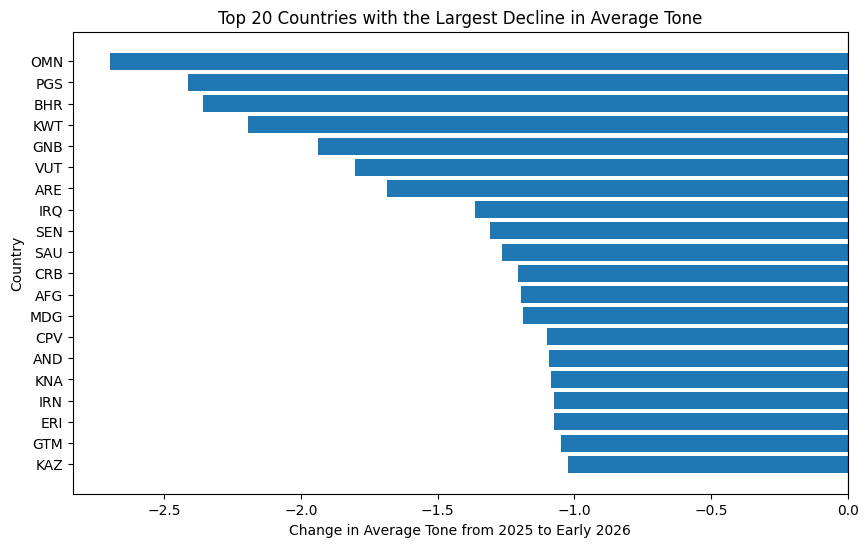

In [102]:
plt.figure(figsize=(10, 6))
plt.barh(
    most_negative_tone_shift["country"],
    most_negative_tone_shift["delta_tone_level"]
)

plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.title("Top 20 Countries with the Largest Decline in Average Tone")
plt.xlabel("Change in Average Tone from 2025 to Early 2026")
plt.ylabel("Country")
plt.show()

In [103]:
most_positive_tone_shift = merged[[
    "country",
    "delta_tone_level",
    "tone_level_2025",
    "tone_level_2026",
    "delta_NVI",
    "NVI_2025",
    "NVI_2026",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_tone_level", ascending=False).head(20)

most_positive_tone_shift

,country,delta_tone_level,tone_level_2025,tone_level_2026,delta_NVI,NVI_2025,NVI_2026,regime_2025,regime_2026
6,NRU,2.339322,-1.158552,1.180770,2.264932,7.193067,9.457999,Shock,Shock
54,SWZ,1.954287,-2.904252,-0.949965,2.132511,2.629633,4.762144,Shock,Shock
57,TZA,1.751862,-0.571890,1.179972,1.310390,1.627102,2.937493,Shock,Shock
63,CAF,1.437047,-2.016474,-0.579427,1.887067,0.823188,2.710255,Moderate,Shock
69,SRB,1.274406,-2.489892,-1.215485,0.731967,0.510409,1.242376,Moderate,Shock
2,EAF,1.274380,-0.918987,0.355393,-0.618285,6.631971,6.013686,Shock,Shock
110,VEN,1.070142,-4.139430,-3.069288,-0.072891,-1.738442,-1.811333,Stable,Stable
178,GNQ,1.022837,-1.595665,-0.572828,1.514661,6.774593,8.289255,Shock,Shock
88,SUR,0.943748,-0.501854,0.441894,-0.597844,3.235258,2.637414,Shock,Shock
60,ATG,0.904555,-0.590624,0.313930,0.179708,1.106005,1.285713,Shock,Shock


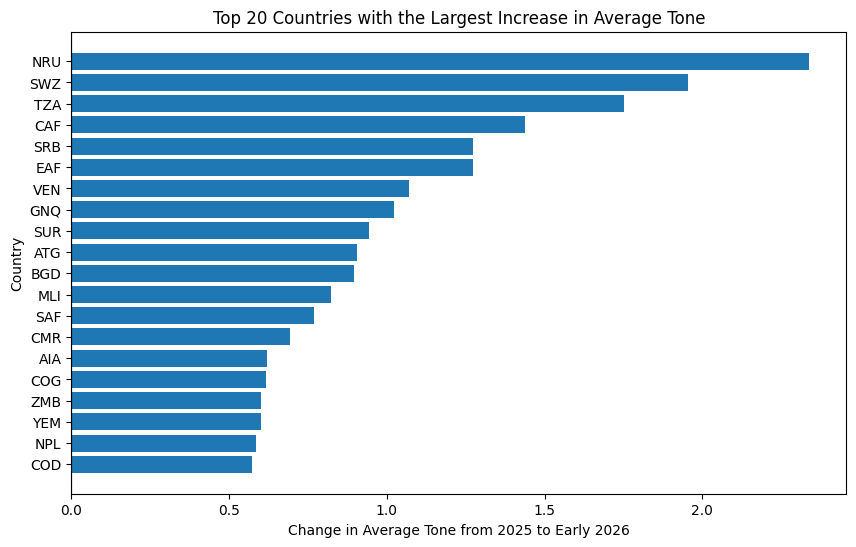

In [104]:
plt.figure(figsize=(10, 6))
plt.barh(
    most_positive_tone_shift["country"],
    most_positive_tone_shift["delta_tone_level"]
)

plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.title("Top 20 Countries with the Largest Increase in Average Tone")
plt.xlabel("Change in Average Tone from 2025 to Early 2026")
plt.ylabel("Country")
plt.show()

The tone-shift analysis shows that changes in average media tone do not always move in the same direction as changes in NVI. Some countries may experience increasing narrative volatility while their average tone becomes more negative, while others may become more volatile but also show a less negative or more positive tone.

This distinction is important because `delta_NVI` measures **how much the narrative became more or less volatile**, while `delta_tone_level` measures **whether the average media tone became more negative or more positive**.

Therefore, tone-shift analysis provides a directional complement to the NVI validation results. It helps identify whether early-2026 changes reflect only stronger volatility or whether they also involve a change in the emotional direction of media coverage.

## 13. Discussion and Interpretation

The out-of-sample validation shows how the NVI framework can be applied beyond the baseline period. By using **2025 normalization parameters** for both 2025 and early-2026 observations, the analysis preserves a consistent scale across periods.

The strongest empirical pattern in this notebook is the concentration of positive NVI shifts among **Gulf countries**. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show positive `delta_NVI` values, and five of these countries move into the **Shock** regime in early 2026.

The directional level analysis adds an important interpretation layer. While `delta_NVI` measures how much narrative volatility changed, changes in average tone and Goldstein scores help indicate whether the narrative also became more negative, more positive, more conflict-oriented, or more cooperation-oriented.

This distinction is especially important in the Gulf results. The Gulf countries show both rising NVI and declining average tone, suggesting that the increase in volatility was accompanied by a more negative media narrative. In several cases, Goldstein levels also decline, suggesting a less cooperation-oriented event profile.

This pattern is **descriptively consistent** with ACLED reporting on the early-2026 Iran-Israel-Gulf escalation. However, the analysis does **not** claim that the conflict directly caused the NVI shifts. Instead, it shows that the NVI framework captures a narrative volatility increase in countries that were also highly relevant to the regional escalation.

The Iran-Israel and Levant group also shows generally positive NVI changes, although the increases are smaller than in the Gulf group and none of the selected countries move into the Shock regime. The directional indicators show that this group is internally mixed: **IRQ**, **IRN**, and **LBN** show increases in NVI together with declining tone and Goldstein levels, while **ISR**, **PSE**, **YEM**, and **JOR** show smaller NVI increases with tone becoming less negative.

The selected African conflict cases also show mixed results. **MLI**, **NER**, and **BFA** show positive NVI changes, but the directional interpretation differs across cases. For example, **MLI** shows a positive NVI shift while its average tone and Goldstein levels increase, whereas **NER** and **BFA** show positive NVI shifts with declining tone and Goldstein levels. This confirms that NVI should be interpreted together with directional indicators.

The tone-shift analysis further reinforces the distinction between volatility and direction. Countries with the largest declines in average tone are not necessarily the same countries with the largest increases in NVI. This means that worsening media tone and increasing narrative volatility should be interpreted as related but distinct signals.

Several limitations should be considered. The 2026 period covers only the **first three months of the year**, so the results should be interpreted as an early-period comparison rather than a full-year validation. In addition, countries with lower event coverage may show larger volatility changes because smaller changes in the underlying indicators can have a stronger effect on rolling volatility.

Overall, the out-of-sample results suggest that the NVI is useful for detecting shifts in narrative volatility, but it should not be interpreted alone. The most informative interpretation comes from reading `delta_NVI` together with changes in tone, Goldstein score, entropy, event coverage, and regime transitions.

## References

ACLED. (2026a). *Middle East Special Issue: March 2026*. Armed Conflict Location & Event Data Project. https://acleddata.com/update/middle-east-special-issue-march-2026

ACLED. (2026b). *Middle East Overview: April 2026*. Armed Conflict Location & Event Data Project. https://acleddata.com/update/middle-east-overview-april-2026

## 14. Summary

This notebook evaluated the NVI framework in an **out-of-sample setting**. The analysis used **2025 as the baseline period** and applied the same normalization parameters to **early-2026 observations**.

Rolling volatility was recomputed across the full timeline before extracting yearly snapshots, ensuring that the 2026 values retained historical context. The recalculated 2025 NVI was validated against the original NVI table, and the near-zero difference confirmed that the pipeline was internally consistent.

The comparison between 2025 and early 2026 identified changes in narrative volatility using `delta_NVI` and regime transitions. The clearest result is the concentration of large positive NVI shifts in the **Gulf countries**. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show increased NVI values, and five of these countries move into the **Shock** regime.

The component-level decomposition shows that these increases are mainly associated with **Goldstein volatility** and **tone volatility**, suggesting changes in both cooperation-conflict signals and media tone.

The notebook also added directional interpretation using average tone, Goldstein, and entropy levels. This helped distinguish **increased volatility** from changes in the **direction or character** of the narrative. The Gulf countries show both increased NVI and declining average tone, while other cases show more mixed patterns.

The Iran-Israel and Levant comparison shows positive but more moderate increases, while the selected African conflict cases show mixed results. These findings support the interpretation that NVI measures **narrative volatility**, not conflict intensity or geopolitical importance directly.

The notebook also compared the largest positive and negative tone shifts between 2025 and early 2026. This showed that changes in average tone provide a directional complement to NVI, helping distinguish whether increased volatility is accompanied by a more negative or more positive media narrative.

Overall, this notebook shows that the NVI can be extended beyond its baseline construction and used to evaluate changes in narrative volatility across time. However, because the 2026 data covers only part of the year, the results should be interpreted as an **early-2026 comparison** rather than a full-year validation.